In [8]:
import numpy as np
import torch
import torch.nn as nn
torch.manual_seed(0)
torch.cuda.manual_seed(0)

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

/home/ubuntu/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Toy Experiment
$d$-dimensional data (in this case 2D) is hidden in $D$-dimensional space, via a random fixed projection matrix. In $D$-dim space, we train a generative model, and observe the models ability to recover the "hidden" data as $D$ increases.

In [2]:
# make spirals
def generate_spiral(n_samples=20_000, num_classes=1,curve=11,spread = 0.01, scale=2):
    D = 2
    K = num_classes
    
    x = torch.zeros((n_samples * K, D), dtype=torch.float32)
    y = torch.zeros(n_samples * K)
    
    for j in range(K):
        idx = slice(n_samples * j, n_samples * (j + 1))
        r = torch.linspace(0.0, 1 * scale, n_samples)
        t = torch.linspace(j * curve, (j + 1) * curve, n_samples) + torch.randn(n_samples) * spread
        x[idx] = torch.stack([r * torch.sin(-t), r * torch.cos(t)], dim=1)
        y[idx] = j
        
    return x, y

Projecting data in $d$ space to $D$ space with $P$ should allow sus to view the original data in $d$ space after projecting back using $P^T$

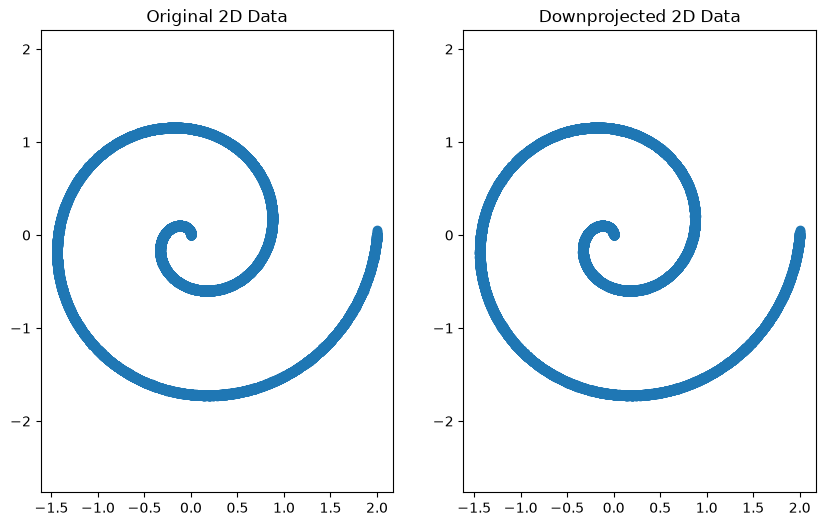

In [3]:
n_samples = 20_000
x_d, _ = generate_spiral(n_samples=n_samples)
# Projection matrix P
P = torch.randn(n_samples, 2)
P, _ = torch.linalg.qr(P)
x_D = x_d @ P.T
x_dp = x_D @ P

plt.figure(figsize=(10, 6))
plt.subplot(1,2,1)
plt.scatter(x_d[:, 0].numpy(), x_d[:, 1].numpy())
plt.title("Original 2D Data")
plt.axis('equal')
plt.subplot(1,2,2)
plt.scatter(x_dp[:, 0].numpy(), x_dp[:, 1].numpy())
plt.title("Downprojected 2D Data")
plt.axis('equal')
plt.show()

### Toy Experiment
Following the paper, we will adopt a 5-layer MLP with ReLU activations. With the original 2D data fixed, we will use $P \in R^{Dxd}$ to project our data into the following dimensions $\{2, 8, 16, 512\}$. The goal of our experiemnt is to visualize the performance of $x$, $\epsilon$, $v$ prediction spaces with common loss space ($v$). 

In [4]:
class MLP(nn.Module):
    def __init__(self, dim, hidden_dim=256, n_layers = 5):
        super().__init__()
        layers = [
            nn.Linear(dim + 1, hidden_dim),
            nn.ReLU(),
        ]
        for _ in range(n_layers - 2):
            layers += [
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
            ]
        layers += [nn.Linear(hidden_dim, dim)]
        self.layers = nn.Sequential(*layers)

    def forward(self, x, t):
        x = torch.cat([x,t], dim = 1)
        return self.layers(x)
        

In [49]:
T_MIN = 0.05

def train_model(
            D,
            data_2d,
            P,
            num_steps,
            batch_size,
            lr,
            val_split,
            param,
            model,
            device,
            sigma,
            mu,
            eval_step,
        ):
    data_2d = data_2d.to(device)
    P = P.to(device)
    X = data_2d @ P.T
    n_samples = data_2d.shape[0]
    perm = torch.randperm(n_samples)
    Xte = X[perm[:int(val_split * n_samples)]]
    Xtr = X[perm[int(val_split * n_samples):]]

    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr = lr)
    mse_loss = nn.MSELoss()
    val_loss = []

    pbar = tqdm(
        range(num_steps),
        desc=f"D={D:>4} | param={param:<3}",
        leave=True,
    )
    last_val = float('nan')

    for i in pbar:
        model.train()
        batch_idx = torch.randint(0, Xtr.shape[0], (batch_size,))
        x = Xtr[batch_idx]

        # following the paper we use logit normal distribution
        t = torch.sigmoid(torch.randn(x.shape[0]) * sigma + mu)[...,None].to(device)
        eps = torch.randn_like(x)
        # linear noise zt = (t*x) + (1 - t)*eps
        z_t = t * x + (1 - t) * eps
        pred = model(z_t, t)

        v_true = x - eps
        
        if param == 'x':
            x_theta = pred
            v_theta = (x_theta - z_t) / (1 - t).clamp(min=T_MIN)
        if param == 'eps':
            eps_theta = pred
            v_theta = (z_t - eps_theta) / t.clamp(min=T_MIN)
        if param == 'v':
            v_theta = pred

        loss = mse_loss(v_theta, v_true)

        opt.zero_grad()
        loss.backward()
        opt.step()
        train_loss_item = loss.item()

        if i % eval_step == 0:
            model.eval()
            t = torch.sigmoid(torch.randn(Xte.shape[0]) * sigma + mu)[...,None].to(device)
            eps = torch.randn_like(Xte)
            z_t = t * Xte + (1 - t) * eps
            v_true = Xte - eps
            with torch.no_grad():
                pred = model(z_t, t)
            if param == 'x':
                x_theta = pred
                v_theta = (x_theta - z_t) / (1 - t).clamp(min=T_MIN)
            if param == 'eps':
                eps_theta = pred
                v_theta = (z_t - eps_theta) / t.clamp(min=T_MIN)
            if param == 'v':
                v_theta = pred

            loss = mse_loss(v_theta, v_true)
            val_loss.append(loss.item() * D)
            last_val = val_loss[-1]
        pbar.set_postfix({
            "train": f"{train_loss_item:.4f}",
            "val * D": f"{last_val:.4f}",
        })

    pbar.close()
    return model, val_loss

            

In [50]:
@torch.no_grad()
def sample(model, timesteps, D, samples, param, device):
    model.eval()
    ts = torch.linspace(0, 1, timesteps+1)
    z_t = torch.randn(samples, D).to(device)
    for i,t in enumerate(ts[:-1]):
        t_batch = t.expand(samples)[...,None].to(device)
        pred = model(z_t, t_batch)
        if param == 'x':
            x_theta = pred
            v_theta = (x_theta - z_t) / (1 - t).clamp(min=T_MIN)
        if param == 'eps':
            eps_theta = pred
            v_theta = (z_t - eps_theta) / t.clamp(min=T_MIN)
        if param == 'v':
            v_theta = pred
        # in real cases the paper ops for 50 step heun but here we opt euler for simplicity (following their pseudocode)
        z_t = z_t + (ts[i+1] - t) * v_theta
    return z_t 


In [51]:
PARAMS = ["x", "eps", "v"]
D_LIST = [2, 8, 16, 512]

data_2d_base, _ = generate_spiral()

def run_experiment(num_steps, device, mu, sigma, sample_timesteps, samples):
    result = {}
    for D in D_LIST:
        P = torch.randn(D, 2)
        P, _ = torch.linalg.qr(P)
        for param in PARAMS:
            model = MLP(dim=D)
            model, val_loss = train_model(D, data_2d_base.clone(), P,num_steps, batch_size=256, lr=0.001, val_split=0.2, param=param, model = model, device = device, mu = mu, sigma=sigma, eval_step=500)
            model_sample = sample(model, sample_timesteps, D, samples, param, device)
            model_sample_2d = model_sample.cpu() @ P
            result[(D, param)] = {"val_loss": val_loss, "model_sample": model_sample_2d}

    return result

result = run_experiment(10_000, "cuda", 0,1, 50, 2_000)

D=   2 | param=x  :   0%|          | 0/10000 [00:00<?, ?it/s, train=4.2554, val * D=13.1048]

D=   2 | param=x  : 100%|██████████| 10000/10000 [00:45<00:00, 221.61it/s, train=1.2146, val * D=2.6100]
D=   2 | param=eps: 100%|██████████| 10000/10000 [00:45<00:00, 220.85it/s, train=1.3161, val * D=2.6917]
D=   2 | param=v  : 100%|██████████| 10000/10000 [00:44<00:00, 226.85it/s, train=1.4336, val * D=2.6376]
D=   8 | param=x  : 100%|██████████| 10000/10000 [00:44<00:00, 223.35it/s, train=0.3515, val * D=2.6668]
D=   8 | param=eps: 100%|██████████| 10000/10000 [00:44<00:00, 224.59it/s, train=0.3558, val * D=2.9940]
D=   8 | param=v  : 100%|██████████| 10000/10000 [00:44<00:00, 224.06it/s, train=0.2972, val * D=2.6746]
D=  16 | param=x  : 100%|██████████| 10000/10000 [00:47<00:00, 211.07it/s, train=0.1455, val * D=2.6133]
D=  16 | param=eps: 100%|██████████| 10000/10000 [00:46<00:00, 213.36it/s, train=0.2610, val * D=3.5989]
D=  16 | param=v  : 100%|██████████| 10000/10000 [00:45<00:00, 217.40it/s, train=0.1776, val * D=2.6811]
D= 512 | param=x  : 100%|██████████| 10000/10000 [00:45

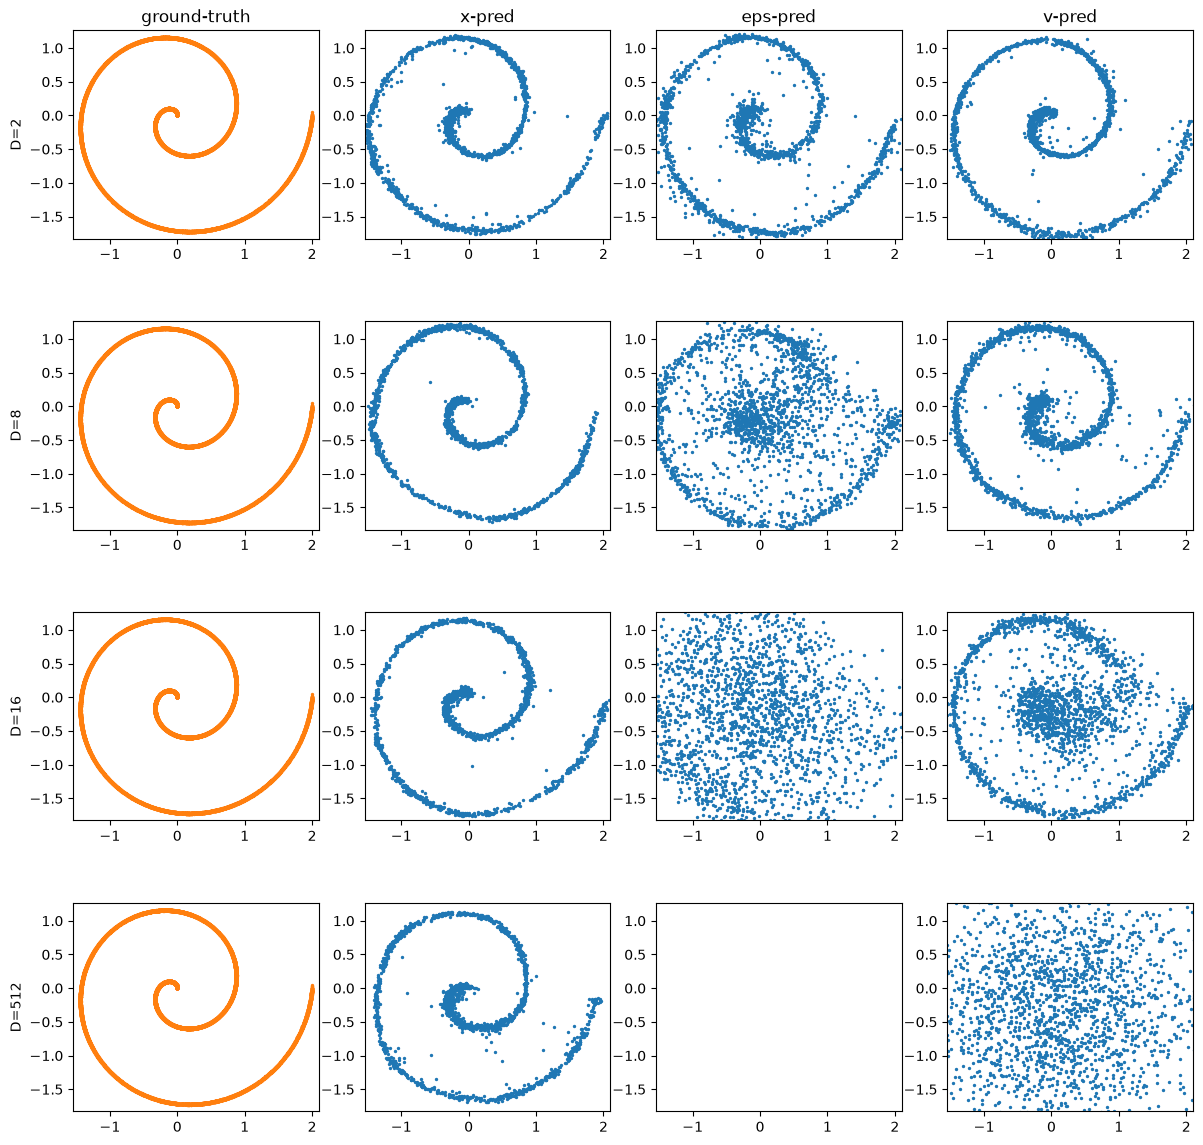

In [ ]:
fig, axes = plt.subplots(
    len(D_LIST),
    1 + len(PARAMS),
    figsize=(3 * (1 + len(PARAMS)), 3 * len(D_LIST)),
    squeeze=False,
)

delta = 0.1
xlim = (data_2d_base[:, 0].min()-delta, data_2d_base[:, 0].max()+delta)
ylim = (data_2d_base[:, 1].min()-delta, data_2d_base[:, 1].max()+delta)

for i, D in enumerate(D_LIST):
    ax = axes[i, 0]
    ax.scatter(
        data_2d_base[:, 0],
        data_2d_base[:, 1],
        s=2,
        color="tab:orange",
    )
    ax.set_title("ground-truth" if i == 0 else "")
    
    for j, param in enumerate(PARAMS, start=1):
        ax = axes[i, j]
        model_sample = result[(D, param)]["model_sample"]

        ax.scatter(
            model_sample[:, 0],
            model_sample[:, 1],
            s=2,
            color="tab:blue",
        )

        if i == 0:
            ax.set_title(f"{param}-pred")

    axes[i, 0].set_ylabel(f"D={D}")

    for j in range(1 + len(PARAMS)):
        axes[i, j].set_xlim(xlim)
        axes[i, j].set_ylim(ylim)
        axes[i, j].set_aspect("equal")

plt.tight_layout()
plt.show()